# Veamos que hacemos

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import MNAF2025 as mna

## Pedirle a gemini que extraiga los datos, se podría hacer analizando pixel a pixel

In [2]:
# Mallado del eje X (Longitud de onda en nm)
# Nota: La gráfica va de derecha a izquierda en el eje superior, 
# aquí los presento en orden ascendente de longitud de onda.
# Mallado del eje X más denso (Longitud de onda en nm)
eje_x = [
    850, 875, 900, 925, 950, 975, 1000, 1020, 1040, 1060, 1080, 
    1100, 1120, 1140, 1160, 1180, 1200, 1225, 1250
]

# Valores extraídos de Reflectancia (curva roja)
reflectancia = [
    0.380, 0.365, 0.350, 0.330, 0.315, 0.305, 0.300, 0.310, 0.320, 
    0.340, 0.370, 0.400, 0.425, 0.440, 0.450, 0.455, 0.460, 0.465, 0.470
]

# Valores extraídos de Transmitancia (curva negra)
transmitancia = [
    0.000, 0.000, 0.000, 0.005, 0.010, 0.020, 0.050, 0.110, 0.190, 
    0.280, 0.375, 0.420, 0.465, 0.495, 0.515, 0.530, 0.540, 0.545, 0.550
]

## Representamos lo que obtenemos

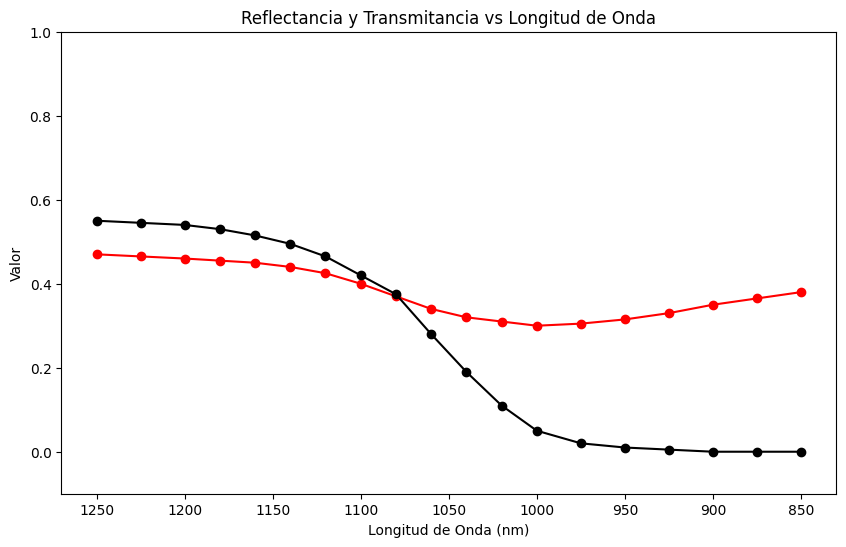

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(eje_x, reflectancia, 'ro-', label='Reflectancia')
plt.plot(eje_x, transmitancia, 'ko-', label='Transmitancia')
plt.xlabel('Longitud de Onda (nm)')
plt.ylabel('Valor')
plt.gca().set_ylim(-0.1, 1)
plt.title('Reflectancia y Transmitancia vs Longitud de Onda')
plt.gca().invert_xaxis()

## Prueba con interpolación parámetrica, función hecha en mnaf

(-0.1, 1.0)

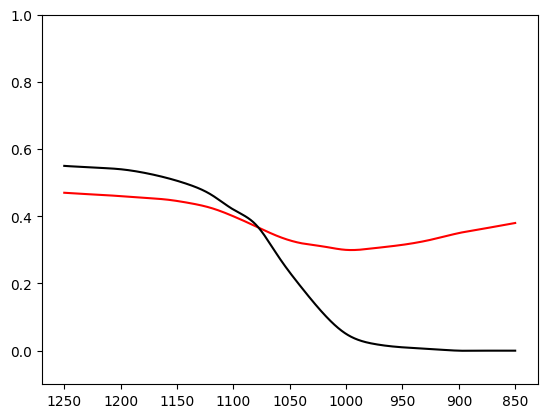

In [4]:
Datos_reflectancia = np.zeros((len(eje_x), 2))
Datos_reflectancia[:, 0] = eje_x
Datos_reflectancia[:, 1] = reflectancia

Datos_transmitancia = np.zeros((len(eje_x), 2))
Datos_transmitancia[:, 0] = eje_x
Datos_transmitancia[:, 1] = transmitancia

Reflectancia, u = mna.itp_parametrica(Datos_reflectancia)

Transmitancia, u = mna.itp_parametrica(Datos_transmitancia)

parametro = np.linspace(0, 1, 10000)

plt.plot(Reflectancia(parametro)[:, 0], Reflectancia(parametro)[:, 1], 'r-', label='Curva Paramétrica')
plt.plot(Transmitancia(parametro)[:, 0], Transmitancia(parametro)[:, 1], 'k-', label='Curva Paramétrica')
plt.gca().invert_xaxis()
plt.ylim(-0.1, 1)

# Obtención rigurosa

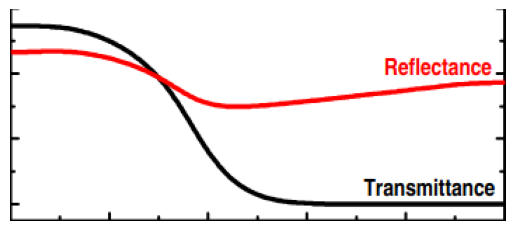

In [116]:
from PIL import Image
import numpy as np

# Abrir la imagen
img = Image.open('/home/edgar/Imágenes/Capturas de pantalla/Captura desde 2026-03-04 12-36-57.png')

# Convertir a matriz de NumPy
matriz = np.array(img)

plt.imshow(matriz)
plt.axis('off') 
plt.show()


grafica_roja = np.zeros((354*151, 2))
grafica_negra = np.zeros((354*151, 2))

division_E = 400/354
division_alt = 0.6/151


altura = 151
ancho = 0
contador_rojo = 0
contador_negro = 0


for i in matriz:
    altura -= 1
    ancho = 0
    if (altura+1)%2 == 0:
        for j in i:
            
            if j[0] != 255 and j[0] != 0:
                if grafica_roja[contador_rojo-1][1] != (altura+1) * division_alt:
                    if grafica_roja[contador_rojo-1][0] != ancho * division_E and ancho > 10 and ancho < 300:
                        grafica_roja[contador_rojo][0] = ancho * division_E
                        grafica_roja[contador_rojo][1] = (altura+1) * division_alt
                        contador_rojo += 1
            elif j[0]>100 and j[1]<50 and j[2]<50:
                    if grafica_negra[contador_negro-1][1] != (altura+1) * division_alt:
                        if grafica_negra[contador_negro-1][0] != ancho * division_E and ancho > 10 and ancho < 300:
                            grafica_negra[contador_negro][0] = ancho * division_E
                            grafica_negra[contador_negro][1] = (altura+1) * division_alt
                            contador_negro += 1
            ancho += 1

altura = 151
ancho = 0



for i in matriz:
    altura -= 1
    ancho = 0
    if (altura+1)%2 == 0:
        for j in i:
            if ancho%7 == 0:
                if j[0]>100 and j[1]<50 and j[2]<50:
                    if ancho > 150:
                                if grafica_negra[contador_negro-1][1] != (altura+1) * division_alt:
                                    grafica_negra[contador_negro][0] = ancho * division_E
                                    grafica_negra[contador_negro][1] = (altura+1) * division_alt
                                    contador_negro += 1
                    elif ancho <50 and ancho>10 and (altura +1) < 122:
                        grafica_negra[contador_negro][0] = ancho * division_E
                        grafica_negra[contador_negro][1] = (altura+1) * division_alt
                        contador_negro += 1
            ancho+=1


altura = 151
ancho = 0



for i in matriz:
    altura -= 1
    ancho = 0
    if (altura+1)%6 == 0:
        for j in i:
            if ancho%7 == 0:
                if j[0]!=255 and j[1]!=255 and j[2]!=255:
                    if ancho > 200 and ancho < 340:
                                
                                    grafica_roja[contador_rojo][0] = ancho * division_E
                                    grafica_roja[contador_rojo][1] = (altura+1) * division_alt
                                    contador_rojo += 1
            ancho+=1
                





(800.0, 1200.0)

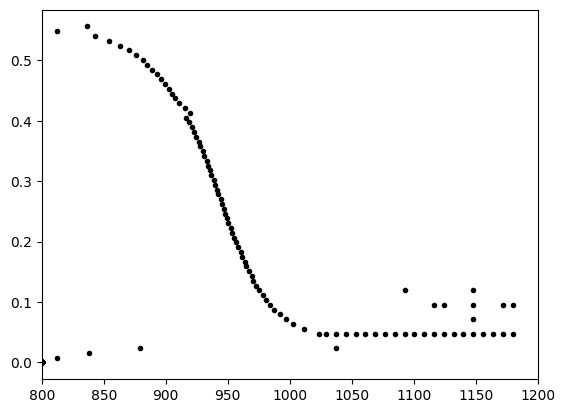

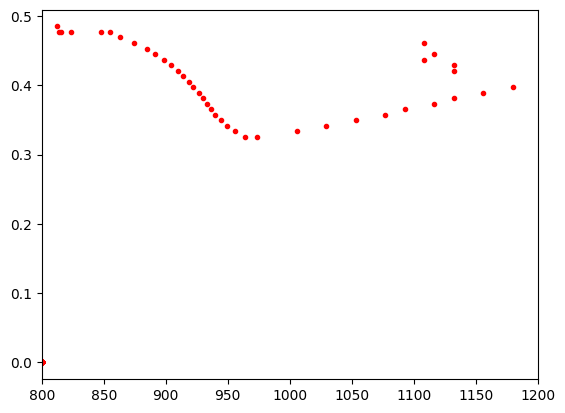

In [117]:
plt.figure()

plt.plot(grafica_roja[:, 0]+800, grafica_roja[:, 1], 'k.')
plt.xlim(800, 1200)

plt.figure()
plt.plot(grafica_negra[:, 0]+800, grafica_negra[:, 1], 'r.')
plt.xlim(800, 1200)

